In [42]:
import rasterio
import numpy as np

with rasterio.open("Tama1987.tif") as src:
    hr = src.read()  # (bands, H, W)

hr = np.transpose(hr, (1,2,0))  # (H, W, C)

In [44]:
import cv2

# Current size
H, W, _ = hr.shape

# Target long side (≈1000 px)
target = 1000

# Scale factor
scale = target / max(H, W)

new_W = int(W * scale)
new_H = int(H * scale)

# Resize
hr = cv2.resize(hr, (new_W, new_H), interpolation=cv2.INTER_AREA)

# Make dimensions divisible by 32 (optional, for CNNs)
new_H = (hr.shape[0] // 32) * 32
new_W = (hr.shape[1] // 32) * 32
hr = hr[:new_H, :new_W]

print("Resized HR image shape:", hr.shape)


Resized HR image shape: (608, 992, 4)


In [53]:
# Make square by center cropping
H, W, C = hr.shape
side = min(H, W)

start_y = (H - side) // 2
start_x = (W - side) // 2

hr = hr[start_y:start_y + side, start_x:start_x + side]

print("Square HR image shape:", hr.shape)


Square HR image shape: (608, 608, 4)


In [62]:
# Ensure RGB only
if hr.shape[2] > 3:
    hr = hr[:, :, :3]

print("RGB image shape:", hr.shape)


RGB image shape: (608, 608, 3)


In [63]:

scale = 2

lr = cv2.resize(
    hr,
    (hr.shape[1]//scale, hr.shape[0]//scale),
    interpolation=cv2.INTER_AREA
)

# Bicubic baseline
bicubic = cv2.resize(
    lr,
    (hr.shape[1], hr.shape[0]),
    interpolation=cv2.INTER_CUBIC
)

print("LR shape:", lr.shape)


LR shape: (304, 304, 3)


In [64]:

lr_input = np.expand_dims(lr, axis=0)
print("AE input shape:", lr_input.shape)

AE input shape: (1, 304, 304, 3)


In [65]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, UpSampling2D, add
from keras.models import Model
from keras import regularizers

# Encoder

n = 64
chan = 3
input_img = Input(shape=(n, n, chan))

l1 = Conv2D(64, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(input_img)
l2 = Conv2D(64, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l1)
l3 = MaxPooling2D(padding='same')(l2)
l3 = Dropout(0.3)(l3)
l4 = Conv2D(128, (3, 3),  padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l3)
l5 = Conv2D(128, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l4)
l6 = MaxPooling2D(padding='same')(l5)
l3 = Dropout(0.5)(l3)
l7 = Conv2D(256, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l6)
encoder = Model(input_img, l7)

In [66]:

encoder.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,328 (2.12 MB)

 Trainable params: 555,328 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:

# Decoder

l8 = UpSampling2D()(l7)

l9 = Conv2D(128, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l8)
l10 = Conv2D(128, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l9)

l11 = add([l5, l10])
l12 = UpSampling2D()(l11)
l3 = Dropout(0.3)(l3)
l13 = Conv2D(64, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l12)
l14 = Conv2D(64, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l13)

l15 = add([l14, l2])

# chan = 3, for RGB
decoded = Conv2D(chan, (3, 3), padding='same', activation='relu', activity_regularizer=regularizers.l1(10e-10))(l15)

# Create our network
autoencoder = Model(input_img, decoded)
# You'll understand later what this is
autoencoder_hfenn = Model(input_img, decoded)

In [68]:


autoencoder.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 64, 64,    │      1,792 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_50[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 32, 32,    │          0 │ conv2d_51[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32, 32,    │          0 │ max_pooling2d_12… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 32, 32,    │     73,856 │ dropout_16[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_52[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ conv2d_53[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_13… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 32, 32,    │          0 │ conv2d_54[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 32, 32,    │    295,040 │ up_sampling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_55[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 32, 32,    │          0 │ conv2d_53[0][0],  │
│                     │ 128)              │            │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 64, 64,    │          0 │ add_8[0][0]       │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 64, 64,    │     73,792 │ up_sampling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_57[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 64, 64,    │          0 │ conv2d_58[0][0],

 Total params: 1,110,403 (4.24 MB)

 Trainable params: 1,110,403 (4.24 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:

autoencoder.compile(optimizer='adadelta', loss='mean_squared_error')

In [70]:

patch_size = 64
scale = 2

X_lr = []
Y_hr = []

for _ in range(500):
    y = np.random.randint(0, hr.shape[0] - patch_size)
    x = np.random.randint(0, hr.shape[1] - patch_size)

    hr_patch = hr[y:y+patch_size, x:x+patch_size]

    lr_patch = cv2.resize(
        hr_patch,
        (patch_size//scale, patch_size//scale),
        interpolation=cv2.INTER_AREA
    )

    lr_patch = cv2.resize(
        lr_patch,
        (patch_size, patch_size),
        interpolation=cv2.INTER_CUBIC
    )

    X_lr.append(lr_patch)
    Y_hr.append(hr_patch)

X_lr = np.array(X_lr, dtype="float32")
Y_hr = np.array(Y_hr, dtype="float32")

history = autoencoder.fit(
    X_lr,
    Y_hr,
    epochs=5,
    batch_size=4,
    validation_split=0.1
)


Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 262ms/step - loss: 14835.7832 - val_loss: 10235.8936
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 32s 283ms/step - loss: 9677.5566 - val_loss: 6666.4214
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 32s 287ms/step - loss: 5003.5210 - val_loss: 6098.2837
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 289ms/step - loss: 4831.5112 - val_loss: 6271.9219
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 32s 285ms/step - loss: 4801.4346 - val_loss: 6140.3433


In [71]:
def sr_patchwise(model, img, patch_size=64):
    H, W, C = img.shape
    sr_img = np.zeros_like(img)

    for y in range(0, H, patch_size):
        for x in range(0, W, patch_size):
            patch = img[y:y+patch_size, x:x+patch_size]


            if patch.shape[0] != patch_size or patch.shape[1] != patch_size:
                continue

            patch = patch[None, ...]
            sr_patch = model.predict(patch, verbose=0)[0]
            sr_img[y:y+patch_size, x:x+patch_size] = sr_patch

    return np.clip(sr_img, 0, 1)

In [72]:

# Create LR version of the full EO image
scale = 2

lr = cv2.resize(
    hr,
    (hr.shape[1]//scale, hr.shape[0]//scale),
    interpolation=cv2.INTER_AREA
)

# Bicubic baseline
bicubic = cv2.resize(
    lr,
    (hr.shape[1], hr.shape[0]),
    interpolation=cv2.INTER_CUBIC
)

# Autoencoder SR
sr = sr_patchwise(autoencoder, bicubic, patch_size=64)
sr = np.clip(sr, 0, 1)

In [73]:

print("HR min/max:", hr.min(), hr.max(), hr.dtype)
print("LR min/max:", lr.min(), lr.max(), lr.dtype)
print("Bicubic min/max:", bicubic.min(), bicubic.max(), bicubic.dtype)
print("SR min/max:", sr.min(), sr.max(), sr.dtype)


HR min/max: 0 236 uint8
LR min/max: 0 228 uint8
Bicubic min/max: 0 227 uint8
SR min/max: 0 1 uint8


In [74]:

def rescale(img):
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img

hr_v  = rescale(hr)
lr_v  = rescale(lr)
bic_v = rescale(bicubic)
sr_v  = rescale(sr)


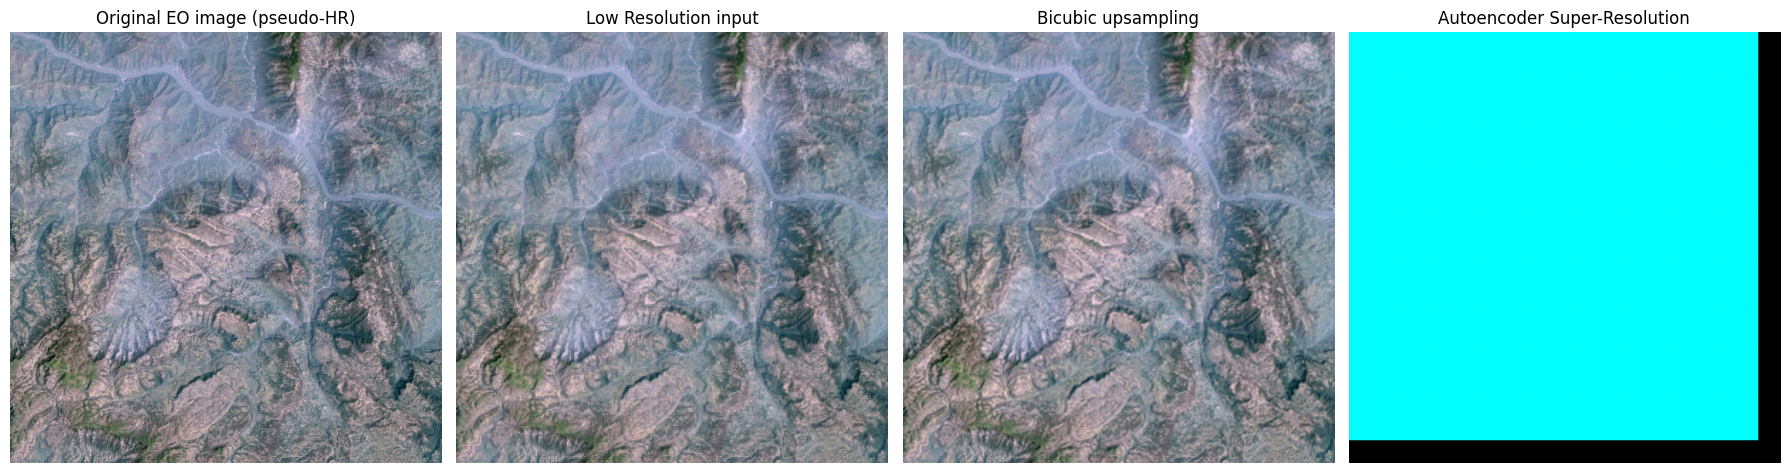

In [75]:

import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.imshow(hr_v)
plt.title("Original EO image (pseudo-HR)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(lr_v)
plt.title("Low Resolution input")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(bic_v)
plt.title("Bicubic upsampling")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(sr_v)
plt.title("Autoencoder Super-Resolution")
plt.axis("off")

plt.tight_layout()
plt.show()


In [76]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("PSNR Bicubic:", psnr(hr, bicubic, data_range=1.0))
print("PSNR AE-SR  :", psnr(hr, sr, data_range=1.0))

print("SSIM Bicubic:", ssim(hr, bicubic, channel_axis=2, data_range=1.0))
print("SSIM AE-SR  :", ssim(hr, sr, channel_axis=2, data_range=1.0))

PSNR Bicubic: -18.700031130197853
PSNR AE-SR  : -41.87227999181366
SSIM Bicubic: 0.7903431384392716
SSIM AE-SR  : 1.7155773126109638e-07


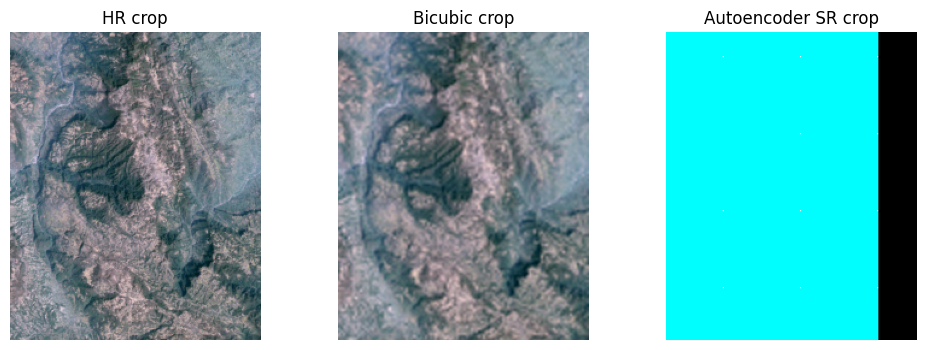

In [77]:
y, x = 300, 400
crop = 256

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(hr_v[y:y+crop, x:x+crop])
plt.title("HR crop")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bic_v[y:y+crop, x:x+crop])
plt.title("Bicubic crop")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sr_v[y:y+crop, x:x+crop])
plt.title("Autoencoder SR crop")
plt.axis("off")

plt.show()
